In [1]:
%load_ext autoreload

import sys
import os
import pandas as pd
import numpy as np
import torch
import copy
import pandas as pd
import torch
import yaml

from portfolio_price_discrete_PPO_sharpe.enviroment import Stock_Env as ppo_stock_env
from portfolio_price_discrete_PPO_sharpe.agent import PPO as ppo_agent
from portfolio_price_discrete_PPO_sharpe.run_monthly import eval_env as ppo_eval_env

from portfolio_price_discrete_SAC_sharpe.enviroment import Stock_Env as sac_stock_env
from portfolio_price_discrete_SAC_sharpe.agent import DiscreteSACAgent as sac_agent
from portfolio_price_discrete_SAC_sharpe.run_monthly import eval_env as sac_eval_env


from portfolio_price_discrete_rebal_step_1m_concat_sharpe.enviroment import Stock_Env as grpo_stock_env
from portfolio_price_discrete_rebal_step_1m_concat_sharpe.agent import PPO as grpo_agent
from portfolio_price_discrete_rebal_step_1m_concat_sharpe.grpo_monthly import test_grpo as grpo_eval_env

Current working directory: /workspace
Current working directory: /workspace
Current working directory: /workspace


In [2]:
# def set_seed(seed):
#     # random.seed(seed)
#     # np.random.seed(seed)
#     torch.manual_seed(seed)
#     # torch.cuda.manual_seed(seed)
#     # torch.cuda.manual_seed_all(seed)  # Multi-GPU 환경 고려
#     # torch.backends.cudnn.deterministic = True
#     # torch.backends.cudnn.benchmark = False
#     print(f"Random seed set to: {seed}")

# SEED = 50
# set_seed(SEED)

In [3]:
ppo_worst_seed = 50
ppo_best_seed = 28
start_date =  "2019-01-01"
end_data = "2024-12-31"

sac_worst_seed = 39
sac_best_seed = 50

grpo_worst_seed = 42
grpo_best_seed = 56

In [4]:
index_train_path = "./data/train_v3.csv"
index_test_path = "./data/test_v3.csv"
future_train_path = "./data/future_train_v3.csv"
future_test_path = "./data/future_test_v3.csv"
test_pt = "./data/portfolio_price/concat_portfolio_test_monthly_v1.pt"
with open("./portfolio_price_discrete_PPO_sharpe/config/test_config.yaml", "r") as f:
    ppo_config = yaml.safe_load(f)
    
device = torch.device(ppo_config.get("device", "cuda:0"))
ppo_config["device"] = device

index_train_for_valid = pd.read_csv(index_train_path, index_col=0)
index_test_df = pd.read_csv(index_test_path, index_col=0)

index_test_all_df = pd.concat([index_train_for_valid, index_test_df], axis=0)
index_test_all_df.reset_index(drop=True, inplace=True)
index_test_all_df.set_index("date", inplace=True)

future_train_for_valid = pd.read_csv(future_train_path, index_col=0)
future_test_df = pd.read_csv(future_test_path, index_col=0)
future_test_all_df = pd.concat([future_train_for_valid, future_test_df], axis=0)
future_test_all_df.reset_index(drop=True, inplace=True)
future_test_all_df.set_index("date", inplace=True)


test_tensor = torch.load(test_pt, map_location=device)
traj_len ="1m"
update_interval = ppo_config["update_interval_map"].get(traj_len, 60)
ppo_config["update_interval"] = update_interval
ppo_config["batch_samples"] = ppo_config["batch_samples"].get(traj_len, 5)
ppo_config["TRADE_START_DATE"] =start_date
ppo_config["TRADE_END_DATE"] = end_data
ppo_env = ppo_stock_env(config=ppo_config, states=test_tensor, index_df=index_test_all_df, future_df = future_test_all_df, eval=True)
    

/tmp/ipykernel_2113293/4033453298.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_tensor = torch.load(test_pt, map_location=device)


In [5]:
# worst_ppo_agent = ppo_agent(ppo_env)
# worst_ppo_model_path =  f"./portfolio_price_discrete_PPO_v1/model/3m_seed_v1/final_3m_actor_lr1e-05_critic_lr1e-06_gamma0.99_entropy_weight0.1_epsilon_0.1mu50_reward_cond_sharpe_seed{ppo_worst_seed}_ppo_model.pth"
# worst_ppo_agent.load(worst_ppo_model_path)
# ppo_worst_model_return, ppo_worst_strategy_returns, ppo_worst_weight_rebal, ppo_worst_strategy_weights = ppo_eval_env(ppo_env, worst_ppo_agent)


best_ppo_agent = ppo_agent(ppo_env)
best_ppo_model_path =  f"./portfolio_price_discrete_PPO_sharpe/model/3m_seed_v3/final_3m_actor_lr1e-05_critic_lr1e-06_gamma0.99_entropy_weight0.1_epsilon_0.1mu100_reward_cond_sharpe_seed{ppo_best_seed}_ppo_model.pth"
best_ppo_agent.load(best_ppo_model_path)
ppo_best_model_return, ppo_best_strategy_returns, ppo_best_weight_rebal, ppo_best_strategy_weights = ppo_eval_env(ppo_env, best_ppo_agent)

/workspace/portfolio_price_discrete_PPO_sharpe/agent.py:277: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.policy_old.load_state_dict(torch.load(model_path, map_locatio

./portfolio_price_discrete_PPO_sharpe/model/3m_seed_v3/final_3m_actor_lr1e-05_critic_lr1e-06_gamma0.99_entropy_weight0.1_epsilon_0.1mu100_reward_cond_sharpe_seed28_ppo_model.pth loaded.
76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-02-23
Day: 2021-02-24 ~ 2021-03-23

/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret

Day: 2023-08-11 ~ 2023-09-08
Day: 2023-09-11 ~ 2023-10-06
Day: 2023-10-09 ~ 2023-11-03
Day: 2023-11-06 ~ 2023-12-04
Day: 2023-12-05 ~ 2024-01-03
Day: 2024-01-04 ~ 2024-02-01
Day: 2024-02-02 ~ 2024-03-01
Day: 2024-03-04 ~ 2024-04-01
Day: 2024-04-02 ~ 2024-04-29
Day: 2024-04-30 ~ 2024-05-28
Day: 2024-05-29 ~ 2024-06-26
Day: 2024-06-27 ~ 2024-07-25
Day: 2024-07-26 ~ 2024-08-22
Day: 2024-08-23 ~ 2024-09-20
Day: 2024-09-23 ~ 2024-10-18
Day: 2024-10-21 ~ 2024-11-15
Day: 2024-11-18 ~ 2024-12-16
Day: 2024-12-17 ~ 2024-12-31
Episode Done


/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret

In [6]:
# ppo_worst_model_return.rename(columns={0: "ppo_worst"}, inplace=True)
ppo_best_model_return.rename(columns={0: "ppo_best"}, inplace=True)

In [7]:
with open("./portfolio_price_discrete_SAC_sharpe/config/test_config.yaml", "r") as f:
    sac_config = yaml.safe_load(f)

In [8]:
sac_config["update_interval"] = update_interval
sac_config["batch_samples"] = sac_config["batch_samples"].get(traj_len, 5)
sac_config["TRADE_START_DATE"] = start_date
sac_config["TRADE_END_DATE"] = end_data
sac_env = sac_stock_env(config=sac_config, states=test_tensor, index_df=index_test_all_df, future_df = future_test_all_df, eval=True)

In [54]:
# worst_sac_agent = sac_agent(sac_env)
# worst_sac_model_path =  f"./portfolio_price_discrete_SAC_v1/model/3m_seed_v3/final_3m_actor_lr1e-05_critic_lr1e-06_gamma0.9_entropy_weight0.1_epsilon_0.1mu50_reward_cond_sharpe_seed{sac_worst_seed}_sac_model.pth"
# worst_sac_agent.load(worst_sac_model_path)
# sac_worst_model_return, sac_worst_strategy_returns, sac_worst_weight_rebal, sac_worst_strategy_weights = sac_eval_env(sac_env, worst_sac_agent)

best_sac_agent = sac_agent(sac_env)
best_sac_model_path =  f"./portfolio_price_discrete_SAC_sharpe/model/3m_seed_v5/final_3m_actor_lr1e-06_critic_lr1e-05_gamma0.9_entropy_weight0.1_epsilon_0.1mu100_reward_cond_sharpe_seed{sac_best_seed}_sac_model.pth"
best_sac_agent.load(best_sac_model_path)
sac_best_model_return, sac_best_strategy_returns, sac_best_weight_rebal, sac_best_strategy_weights = sac_eval_env(sac_env, best_sac_agent)



/workspace/portfolio_price_discrete_SAC_sharpe/agent.py:253: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=self.device)
/workspace

./portfolio_price_discrete_SAC_sharpe/model/3m_seed_v5/final_3m_actor_lr1e-06_critic_lr1e-05_gamma0.9_entropy_weight0.1_epsilon_0.1mu100_reward_cond_sharpe_seed50_sac_model.pth loaded.
76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-02-23
Day: 2021-02-24 ~ 2021-03-23


/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret

Day: 2024-01-04 ~ 2024-02-01
Day: 2024-02-02 ~ 2024-03-01
Day: 2024-03-04 ~ 2024-04-01
Day: 2024-04-02 ~ 2024-04-29
Day: 2024-04-30 ~ 2024-05-28
Day: 2024-05-29 ~ 2024-06-26
Day: 2024-06-27 ~ 2024-07-25
Day: 2024-07-26 ~ 2024-08-22
Day: 2024-08-23 ~ 2024-09-20
Day: 2024-09-23 ~ 2024-10-18
Day: 2024-10-21 ~ 2024-11-15
Day: 2024-11-18 ~ 2024-12-16
Day: 2024-12-17 ~ 2024-12-31
Episode Done


/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret

In [55]:
# sac_worst_model_return.rename(columns={0: "sac_worst"}, inplace=True)
sac_best_model_return.rename(columns={0: "sac_best"}, inplace=True)

In [56]:
with open("./portfolio_price_discrete_rebal_step_1m_concat_sharpe/config/test_config.yaml", "r") as f:
    grpo_config = yaml.safe_load(f)

In [57]:
update_interval = grpo_config["update_interval_map"].get(traj_len, 60)
grpo_config["update_interval"] = update_interval
grpo_config["batch_samples"] = grpo_config["batch_samples"].get(traj_len, 5)
grpo_config["TRADE_START_DATE"] = "2019-01-01"
grpo_config["TRADE_END_DATE"] = "2024-12-31"
grpo_env = grpo_stock_env(config=grpo_config, states=test_tensor, index_df=index_test_all_df, future_df = future_test_all_df, eval=True)


In [58]:
grpo_worst_seed

42

In [59]:
# worst_grpo_agent = grpo_agent(grpo_env, eval=True)
# worst_grpo_model_path =  f"./portfolio_price_discrete_rebal_step_1m_concat_sharpe/model/good result/final_1m_actor_lr1e-06_clip_grad1_epslion_0.2batch_sample_2048_mu100_num_group16_num_steps10_reward_cond_sharpe_seed{grpo_worst_seed}_grpo_model.pth"
# worst_grpo_agent.load(worst_grpo_model_path)
# grpo_worst_model_return, grpo_worst_strategy_returns, grpo_worst_weight_rebal, grpo_worst_strategy_weights = grpo_eval_env(grpo_env, worst_grpo_agent)


best_grpo_agent = grpo_agent(grpo_env, eval=True)
best_grpo_model_path =  f"./portfolio_price_discrete_rebal_step_1m_concat_sharpe/model/good_result_final/final_1m_actor_lr1e-06_clip_grad1_epslion_0.2batch_sample_2048_mu50_num_group16_num_steps10_reward_cond_sharpe_seed{grpo_best_seed}_grpo_model.pth"
best_grpo_agent.load(best_grpo_model_path)
grpo_best_model_return, grpo_best_strategy_returns, grpo_best_weight_rebal, grpo_best_strategy_weights = grpo_eval_env(grpo_env, best_grpo_agent)



/workspace/portfolio_price_discrete_rebal_step_1m_concat_sharpe/agent.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_state = torch.load(model_path, map_location=s

./portfolio_price_discrete_rebal_step_1m_concat_sharpe/model/good_result_final/final_1m_actor_lr1e-06_clip_grad1_epslion_0.2batch_sample_2048_mu50_num_group16_num_steps10_reward_cond_sharpe_seed56_grpo_model.pth loaded.
76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-

In [60]:
# grpo_worst_model_return.rename(columns={0: "grpo_worst"}, inplace=True)
grpo_best_model_return.rename(columns={0: "grpo_best"}, inplace=True)

In [61]:
startegy_equal = grpo_best_strategy_returns["risk_parity"] + grpo_best_strategy_returns["min_var"] +  grpo_best_strategy_returns["max_sharpe"] + grpo_best_strategy_returns["paa"]
startegy_equal = startegy_equal/4

In [62]:
grpo_best_strategy_returns["equal_strategy"] = startegy_equal

In [63]:
# key 이름 바꾸기: equal → equal_weight
if "equal" in grpo_best_strategy_returns.keys():
    grpo_best_strategy_returns["equal_asset_weight"] = grpo_best_strategy_returns.pop("equal")

In [64]:
# grpo_best_strategy_returns["ppo_worst"] = ppo_worst_model_return["ppo_worst"]
# grpo_best_strategy_returns["sac_worst"] = sac_worst_model_return["sac_worst"]
# grpo_best_strategy_returns["grpo_worst"] = grpo_worst_model_return["grpo_worst"]

grpo_best_strategy_returns["ppo_best"] = ppo_best_model_return["ppo_best"]
grpo_best_strategy_returns["sac_best"] = sac_best_model_return["sac_best"]
grpo_best_strategy_returns["grpo_best"] = grpo_best_model_return["grpo_best"]

In [65]:
def calculate_annual_return(returns, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    cumulative = np.prod(1 + returns)
    n_periods = len(returns)
    return cumulative ** (annual_factor / n_periods) - 1


def calculate_max_drawdown(returns):
    returns = np.array(returns, dtype=np.float64)
    cumulative_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdowns = (cumulative_returns - running_max) / running_max
    return abs(np.min(drawdowns))

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


def calculate_downside_deviation(returns, threshold=0.0, annual_factor=252, annualize=True):
    downside = np.minimum(returns - threshold, 0)
    dd = np.sqrt(np.mean(downside ** 2))
    return dd * np.sqrt(annual_factor) if annualize else dd


def calculate_annualized_sortino_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    annual_return = calculate_annual_return(returns, annual_factor)
    excess_return = annual_return - risk_free_rate
    downside_dev = calculate_downside_deviation(returns, threshold=0.0, annual_factor=annual_factor)
    return excess_return / downside_dev if downside_dev != 0 else 0.0


def calculate_calmar_ratio(returns, annual_factor=252):
    """
    Calmar Ratio = Annualized Return / Maximum Drawdown
    """
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    max_drawdown = calculate_max_drawdown(returns)
    
    return  (annual_return) / max_drawdown if max_drawdown != 0 else 0.0  # MDD가 0이면 0 반환


# def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=12):
#     returns = np.array(returns, dtype=np.float64)
#     geo_return = np.prod(1 + returns) ** (1 / len(returns)) - 1
#     risk_free_rate /= annual_factor
#     excess_geo_return = geo_return - risk_free_rate
#     std_dev = np.std(returns, ddof=1)
#     return (excess_geo_return * annual_factor) / (std_dev * np.sqrt(annual_factor)) if std_dev != 0 else 0.0

def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    excess_return =  (annual_return - risk_free_rate) 
    if excess_return == 0:
        sign = 1
    else:
        sign = excess_return / abs(excess_return)
    annual_std_dev = calculate_volatility(returns, annual_factor)
    # 연환산 수익률과 표준편차
    modified_sharpe =  excess_return / (annual_std_dev ** sign)  if annual_std_dev != 0 else 0.0
    return modified_sharpe


def calculate_cumulative_return(returns):
    returns = np.array(returns, dtype=np.float64)
    return np.prod(1 + returns) - 1

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


# 성과 지표 계산 함수 (파라미터화)
def calculate_performance_metrics(returns, annual_factor=252, risk_free_rate=0.0):
    cumulative_returns = (1 + returns).cumprod()
    # cagr = calculate_cagr(returns, annual_factor)
    annual_return = calculate_annual_return(returns, annual_factor)
    sharpe_ratio = calculate_sharpe_ratio(returns, risk_free_rate, annual_factor)
    mdd = calculate_max_drawdown(returns)
    volatility = calculate_volatility(returns, annual_factor)
    sortino_ratio = calculate_annualized_sortino_ratio(returns, risk_free_rate, annual_factor)
    downside_deviation = calculate_downside_deviation(returns, threshold=0.0, annual_factor=annual_factor)
    # Calmar Ratio 계산
    calmar_ratio = calculate_calmar_ratio(returns, annual_factor)
    

    return {
        'Cumulative Return': cumulative_returns.iloc[-1] - 1,
        'Annual Return': annual_return,
        # 'CAGR': cagr,
        'Volatility': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'MDD': mdd,
        'Downside Deviation': downside_deviation,
        'Sortino Ratio': sortino_ratio,
        'Calmar Ratio': calmar_ratio
    }


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


import matplotlib.pyplot as plt
import numpy as np




In [66]:
metrics_summary = get_performance_summary(
    grpo_best_strategy_returns,
    annual_factor=12,
    risk_free_rate=0.0
)

display(metrics_summary)


,Cumulative Return,Annual Return,Volatility,Sharpe Ratio,MDD,Downside Deviation,Sortino Ratio,Calmar Ratio
risk_parity,0.483225,0.064223,0.144680,0.443898,0.237834,0.100482,0.639150,0.270033
min_var,0.789562,0.096244,0.105493,0.912327,0.171656,0.064117,1.501081,0.560681
max_sharpe,0.691300,0.086513,0.192780,0.448764,0.409078,0.114221,0.757414,0.211482
paa,0.168702,0.024920,0.212708,0.117157,0.470926,0.146801,0.169756,0.052918
equal_strategy,0.559529,0.072686,0.137197,0.529793,0.265680,0.094572,0.768581,0.273586
equal_asset_weight,0.507161,0.066917,0.153110,0.437048,0.307545,0.104923,0.637771,0.217583
ppo_best,1.540447,0.158599,0.200694,0.790252,0.306030,0.123554,1.283645,0.518246
sac_best,2.024326,0.190937,0.163054,1.171005,0.161672,0.071914,2.655076,1.181013
grpo_best,1.942343,0.185780,0.163260,1.137943,0.179519,0.078234,2.374672,1.034880


In [67]:
total_df = pd.DataFrame(grpo_best_strategy_returns)

In [68]:
zero_row = pd.DataFrame([[0]*total_df.shape[1]], columns=total_df.columns)


In [69]:
zero_row.index = ["2019-01-01"]

In [70]:
total_df = pd.concat([zero_row, total_df])


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_cumulative_returns_from_df(returns_df: pd.DataFrame,
                                     title='Cumulative Returns',
                                     y_range=(0.0, 5),
                                     test_start_date=None):

    plt.figure(figsize=(25, 8))

    # 누적 로그 수익률 계산
    cum_returns = np.log1p(returns_df).cumsum()

    # 강조할 전략
    bold_strategies = ['grpo_best', 'grpo_worst']

    # 더 구분되는 색상 팔레트 사용
    color_map = {
        'risk_parity': '#1f77b4',          # Blue
        'min_var': '#ff7f0e',              # Orange
        'max_sharpe': '#2ca02c',           # Green
        'paa': '#d62728',                  # Red
        'equal_strategy': '#9467bd',       # Purple
        'equal_asset_weight': '#8c564b',   # Brown

        'ppo_best': '#17becf',             # Teal
        'ppo_worst': '#bcbd22',            # Olive
        'sac_best': '#e377c2',             # Pink
        'sac_worst': '#7f7f7f',            # Gray
        'grpo_best': '#000000',            # Black (굵은)
        'grpo_worst': '#ff0000',           # Bright Red (굵은)
    }

    for col in cum_returns.columns:
        linewidth = 3.5 if col in bold_strategies else 2.0
        color = color_map.get(col, None)

        plt.plot(
            cum_returns.index,
            cum_returns[col],
            label=col,
            linewidth=linewidth,
            color=color
        )

    # x축 날짜 형식

    plt.xticks(rotation=45, fontsize=14)

    if test_start_date:
        plt.axvline(x=test_start_date, color='red', linestyle='--', linewidth=2, label='Test Start')

    plt.ylim(y_range)
    plt.yticks(fontsize=18)
    plt.ylabel('Log Cumulative Returns', fontsize=18)

    plt.xlabel('Date', fontsize=16)
    plt.title(title, fontsize=20)
    plt.legend(loc='upper left', fontsize=16, ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


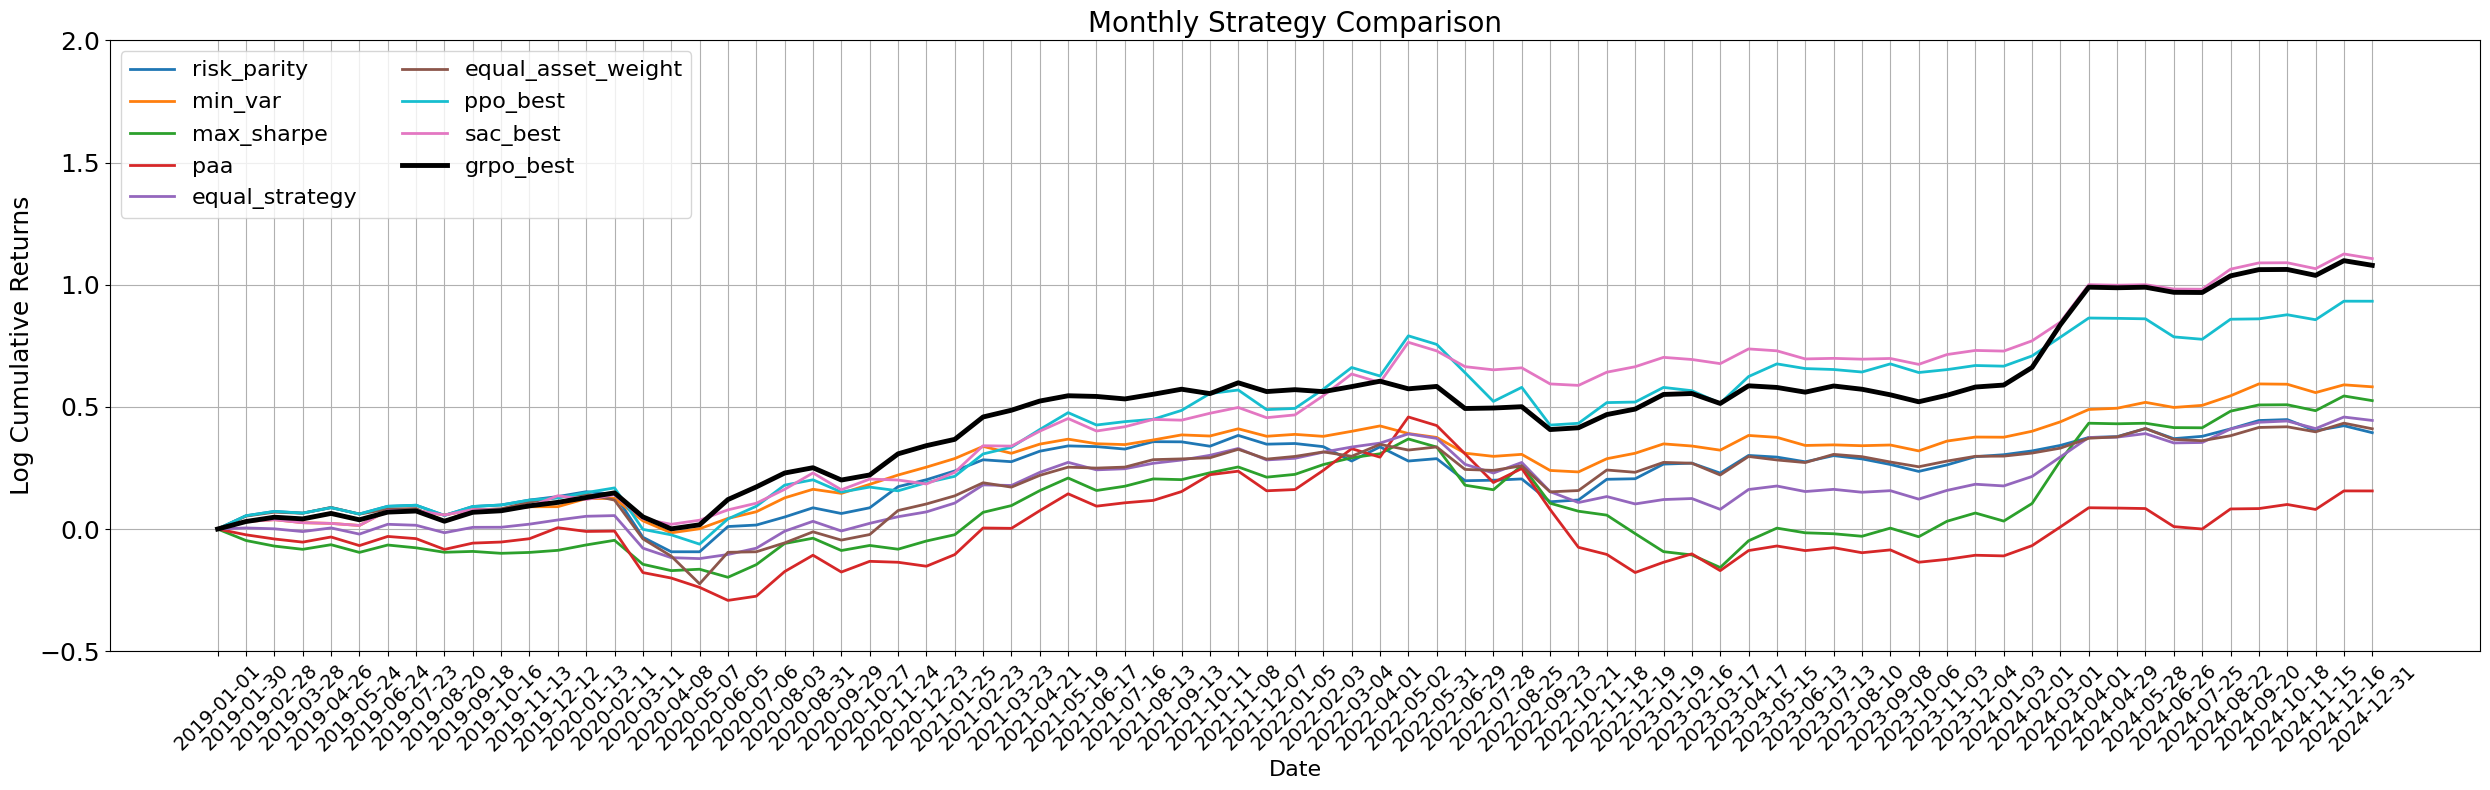

In [72]:
plot_cumulative_returns_from_df(total_df, title="Monthly Strategy Comparison", y_range=(-0.5, 2))


In [73]:
sac_best_strategy_weights.keys()

dict_keys(['risk_parity', 'min_var', 'max_sharpe', 'paa', 'equal'])

In [74]:
sac_best_weight_rebal

,risk_parity,min_var,max_sharpe,paa
2019-01-02,0.0,1.0,0.0,0.0
2019-01-31,0.0,1.0,0.0,0.0
2019-03-01,0.0,1.0,0.0,0.0
2019-03-29,0.0,1.0,0.0,0.0
2019-04-29,0.0,1.0,0.0,0.0
...,...,...,...,...
2024-08-23,0.0,0.0,1.0,0.0
2024-09-23,0.0,0.0,1.0,0.0
2024-10-21,0.0,0.0,1.0,0.0
2024-11-18,0.0,0.0,1.0,0.0


In [75]:
grpo_best_strategy_weights["risk_parity"].columns

Index(['Australia', 'Austria', 'Belgium', 'Canada', 'Cocoa', 'Coffee',
       'Copper', 'Corn', 'Cotton', 'Crude Oil', 'France', 'Germany', 'Gold',
       'Heating Oil', 'Hong Kong', 'Italy', 'Japan', 'Malaysia', 'Mexico',
       'Natural Gas', 'Netherlnd', 'SP500', 'Silver', 'Singapore',
       'Soybean Oil', 'Spain', 'Sugar', 'Sweden', 'Switzrlnd', 'Utd_Kgdm'],
      dtype='object')

In [76]:
# # # 예시: 자산 분류 딕셔너리
# # asset_categories = {
# #     'Equity (선진국)': [
# #         'Australia', 'Austria', 'Belgium', 'Canada', 'France', 'Germany',
# #         'Hong Kong', 'Italy', 'Japan', 'Netherlnd', 'SP500', 'Singapore',
# #         'Spain', 'Sweden', 'Switzrlnd', 'Utd_Kgdm'
# #     ],
# #     'Equity': [
# #         'Malaysia', 'Mexico'
# #     ],
# #     'Energy (에너지)': [
# #         'Crude Oil', 'Natural Gas', 'Heating Oil'
# #     ],
# #     'Commodity - Metals (금속)': [
# #         'Gold', 'Silver', 'Copper'
# #     ],
# #     'Commodity - Agriculture (농산물)': [
# #         'Corn', 'Soybean Oil'
# #     ],
# #     'Commodity - Softs (소프트 커모디티)': [
# #         'Cocoa', 'Coffee', 'Cotton', 'Sugar'
# #     ]
# # }

# # 예시 데이터프레임 불러오기
# df = pd.read_csv("your_data.csv", index_col=0, parse_dates=True)

# # 멀티 인덱스를 위한 열 리벨링
# new_columns = []
# for col in df.columns:
#     found = False
#     for category, assets in asset_categories.items():
#         if col in assets:
#             new_columns.append((category, col))
#             found = True
#             break
#     if not found:
#         new_columns.append(('기타', col))

# # 멀티 인덱스 설정
# df.columns = pd.MultiIndex.from_tuples(new_columns)

# # 확인
# import matplotlib.pyplot as plt
# df.loc["2019-01-30"].T.sort_index().unstack().plot(kind='bar', figsize=(14,6))
# plt.title("2019-01-30 수익률 (자산군별)")
# plt.ylabel("Return")
# plt.tight_layout()
# plt.show()


In [77]:
grpo_best_strategy_weights.keys()

dict_keys(['risk_parity', 'min_var', 'max_sharpe', 'paa', 'equal'])

In [78]:
grpo_best_strategy_weights["risk_parity"]

,Australia,Austria,Belgium,Canada,Cocoa,Coffee,Copper,Corn,Cotton,Crude Oil,...,Netherlnd,SP500,Silver,Singapore,Soybean Oil,Spain,Sugar,Sweden,Switzrlnd,Utd_Kgdm
date,,,,,,,,,,,,,,,,,,,,,
2019-01-30,0.042826,0.031009,0.045224,0.046439,0.008850,0.013741,0.025910,0.029199,0.019265,0.010452,...,0.046659,0.034144,0.031042,0.022250,0.049297,0.036200,0.011387,0.031106,0.049305,0.046797
2019-02-28,0.040726,0.029809,0.044262,0.044989,0.009096,0.013936,0.025820,0.029551,0.020215,0.009935,...,0.044778,0.032571,0.032908,0.022604,0.049698,0.037234,0.011145,0.030199,0.049844,0.045602
2019-03-28,0.039580,0.030146,0.044115,0.047098,0.008609,0.012840,0.025282,0.027419,0.019785,0.009335,...,0.044940,0.036105,0.033064,0.021832,0.046656,0.037561,0.010632,0.031091,0.053306,0.047072
2019-04-26,0.041920,0.029215,0.041941,0.049198,0.008792,0.012326,0.025462,0.026433,0.019165,0.009479,...,0.044142,0.037564,0.032044,0.022166,0.048694,0.036036,0.011309,0.031031,0.054446,0.045898
2019-05-24,0.040282,0.028258,0.040329,0.050061,0.009189,0.011132,0.024250,0.025634,0.019462,0.009331,...,0.043533,0.041178,0.034545,0.022602,0.046577,0.035083,0.011035,0.031128,0.055834,0.045430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-20,0.031556,0.041497,0.043084,0.046474,0.002917,0.007707,0.023707,0.023758,0.016224,0.012309,...,0.028618,0.066188,0.011721,0.047474,0.014562,0.038153,0.011297,0.031101,0.059373,0.061431
2024-10-18,0.031881,0.041351,0.044466,0.047453,0.002608,0.008176,0.024068,0.023363,0.016420,0.011719,...,0.028509,0.066286,0.011632,0.048832,0.014256,0.039563,0.010904,0.031942,0.060903,0.063072
2024-11-15,0.034071,0.042339,0.047695,0.051688,0.002435,0.007605,0.022159,0.022894,0.016376,0.011356,...,0.026861,0.068170,0.011149,0.050822,0.013823,0.041028,0.010606,0.032338,0.062985,0.064853


In [79]:
risk_parity_weights = grpo_best_strategy_weights["risk_parity"]
min_var_weights = grpo_best_strategy_weights["min_var"]
max_sharpe_weights = grpo_best_strategy_weights["max_sharpe"]
paa_weights = grpo_best_strategy_weights["paa"]

In [80]:
risk_parity_weights.index = grpo_best_weight_rebal.index
min_var_weights.index = grpo_best_weight_rebal.index
max_sharpe_weights.index = grpo_best_weight_rebal.index
paa_weights.index = grpo_best_weight_rebal.index

In [81]:
def categorize_and_group_returns(df: pd.DataFrame) -> pd.DataFrame:
    """
    그룹별 자산 수익률을 평균하여 새 데이터프레임으로 반환하는 함수.
    그룹은 Energy, Metals, Agriculture, Developed Equity, Emerging Equity로 나뉜다.
    """

    # 자산 그룹 정의
    asset_groups = {
        'Energy': ['Crude Oil', 'Heating Oil', 'Natural Gas'],
        'Metals': ['Copper'],
        "Precious Metals": ['Gold', 'Silver'],
        'Agriculture': ['Corn', 'Soybean Oil', 'Sugar'],
        'Developed Equity': [
            'Australia', 'Austria', 'Belgium', 'Canada', 'France', 'Germany',
            'Hong Kong', 'Italy', 'Japan', 'Netherlnd', 'SP500', 'Singapore',
            'Spain', 'Sweden', 'Switzrlnd', 'Utd_Kgdm'
        ],
        'Emerging Equity': ['Malaysia', 'Mexico']
    }

    # 실제 존재하는 컬럼만 필터링
    for group in asset_groups:
        asset_groups[group] = [col for col in asset_groups[group] if col in df.columns]

    # 그룹별 평균 수익률 계산
    grouped_df = pd.DataFrame(index=df.index)
    for group_name, assets in asset_groups.items():
        if assets:  # 해당 그룹에 속한 자산이 있는 경우만
            grouped_df[group_name] = df[assets].sum(axis=1)

    return grouped_df


In [82]:
risk_parity_grouped = categorize_and_group_returns(risk_parity_weights)
min_var_grouped = categorize_and_group_returns(min_var_weights)
max_sharpe_grouped = categorize_and_group_returns(max_sharpe_weights)
paa_grouped = categorize_and_group_returns(paa_weights)

In [83]:
risk_parity_grouped.index = pd.to_datetime(risk_parity_grouped.index)
min_var_grouped.index = pd.to_datetime(min_var_grouped.index)
max_sharpe_grouped.index = pd.to_datetime(max_sharpe_grouped.index)
paa_grouped.index = pd.to_datetime(paa_grouped.index)

In [84]:
strategy_grouped_weights = {
    "risk_parity": risk_parity_grouped,
    "min_var": min_var_grouped,
    "max_sharpe": max_sharpe_grouped,
    "paa": paa_grouped
}


In [85]:
grpo_best_weight_rebal.index = pd.to_datetime(grpo_best_weight_rebal.index)
ppo_best_weight_rebal.index = pd.to_datetime(ppo_best_weight_rebal.index)
sac_best_weight_rebal.index = pd.to_datetime(sac_best_weight_rebal.index)


In [86]:
risk_parity_grouped.index

DatetimeIndex(['2019-01-02', '2019-01-31', '2019-03-01', '2019-03-29',
               '2019-04-29', '2019-05-28', '2019-06-25', '2019-07-24',
               '2019-08-21', '2019-09-19', '2019-10-17', '2019-11-14',
               '2019-12-13', '2020-01-14', '2020-02-12', '2020-03-12',
               '2020-04-09', '2020-05-08', '2020-06-08', '2020-07-07',
               '2020-08-04', '2020-09-01', '2020-09-30', '2020-10-28',
               '2020-11-25', '2020-12-24', '2021-01-26', '2021-02-24',
               '2021-03-24', '2021-04-22', '2021-05-20', '2021-06-18',
               '2021-07-19', '2021-08-16', '2021-09-14', '2021-10-12',
               '2021-11-09', '2021-12-08', '2022-01-06', '2022-02-04',
               '2022-03-07', '2022-04-04', '2022-05-03', '2022-06-01',
               '2022-06-30', '2022-07-29', '2022-08-26', '2022-09-26',
               '2022-10-24', '2022-11-21', '2022-12-20', '2023-01-20',
               '2023-02-17', '2023-03-20', '2023-04-18', '2023-05-16',
      

In [87]:
def get_selected_group_weights(
    selected_strategies_df: pd.DataFrame,
    strategy_grouped_weights: dict
) -> pd.DataFrame:
    """
    선택된 전략에 따라 해당 전략의 자산군 weight를 추출하여 통합된 DataFrame을 반환

    Parameters:
    - selected_strategies_df: 전략 선택 테이블 (0 또는 1 값만 가짐)
    - strategy_grouped_weights: 전략 이름 → 자산군별 weight DataFrame (dict)

    Returns:
    - DataFrame: 선택된 전략 기준의 자산군별 weight 시계열
    """
    result = []

    for date, row in selected_strategies_df.iterrows():
        selected = row[row == 1.0]
        if selected.empty:
            continue  # 선택된 전략 없음
        strategy = selected.index[0]
        strategy_weights = strategy_grouped_weights[strategy]

        if date in strategy_weights.index:
            selected_row = strategy_weights.loc[date].copy()
            selected_row.name = date
            result.append(selected_row)
        else:
            print(f"[경고] {strategy} 전략에서 {date} 없음. 생략됨.")

    return pd.DataFrame(result)

In [88]:
final_grpo_weights = get_selected_group_weights(grpo_best_weight_rebal, strategy_grouped_weights)

final_ppo_weights = get_selected_group_weights(ppo_best_weight_rebal, strategy_grouped_weights)
final_sac_weights = get_selected_group_weights(sac_best_weight_rebal, strategy_grouped_weights)

KeyError: 'Risk Parity'

In [89]:
def add_cash_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    각 행의 weight 합이 1이 안 되는 경우, 남은 비중을 'Cash' 열로 추가한다.

    Parameters:
    - df: 자산군별 weight DataFrame

    Returns:
    - df_with_cash: 'Cash' 열이 추가된 DataFrame
    """
    df_with_cash = df.copy()
    total_weight = df_with_cash.sum(axis=1)
    df_with_cash["Cash"] = 1.0 - total_weight
    return df_with_cash


In [90]:
final_ppo_weights_with_cash = add_cash_column(final_ppo_weights)
final_sac_weights_with_cash = add_cash_column(final_sac_weights)
final_grpo_weights_with_cash = add_cash_column(final_grpo_weights)


In [91]:
# final_ppo_weights_with_cash.to_csv("final_ppo_weights_with_cash.csv")
# final_sac_weights_with_cash.to_csv("final_sac_weights_with_cash.csv")
# final_grpo_weights_with_cash.to_csv("final_grpo_weights_with_cash.csv")

In [92]:
grpo_best_weight_rebal.index = grpo_best_weight_rebal.index.strftime('%Y-%m-%d')
ppo_best_weight_rebal.index = ppo_best_weight_rebal.index.strftime('%Y-%m-%d')
sac_best_weight_rebal.index = sac_best_weight_rebal.index.strftime('%Y-%m-%d')

In [93]:
rename_col = {"risk_parity" : "Risk Parity",
 "min_var" : "Min Var",
 "max_sharpe" : "Max Sharpe",
 "paa" : "PAA"
}
grpo_best_weight_rebal.rename(columns=rename_col, inplace=True)
ppo_best_weight_rebal.rename(columns=rename_col, inplace=True)
sac_best_weight_rebal.rename(columns=rename_col, inplace=True)

In [1]:
grpo_best_weight_rebal

NameError: name 'grpo_best_weight_rebal' is not defined

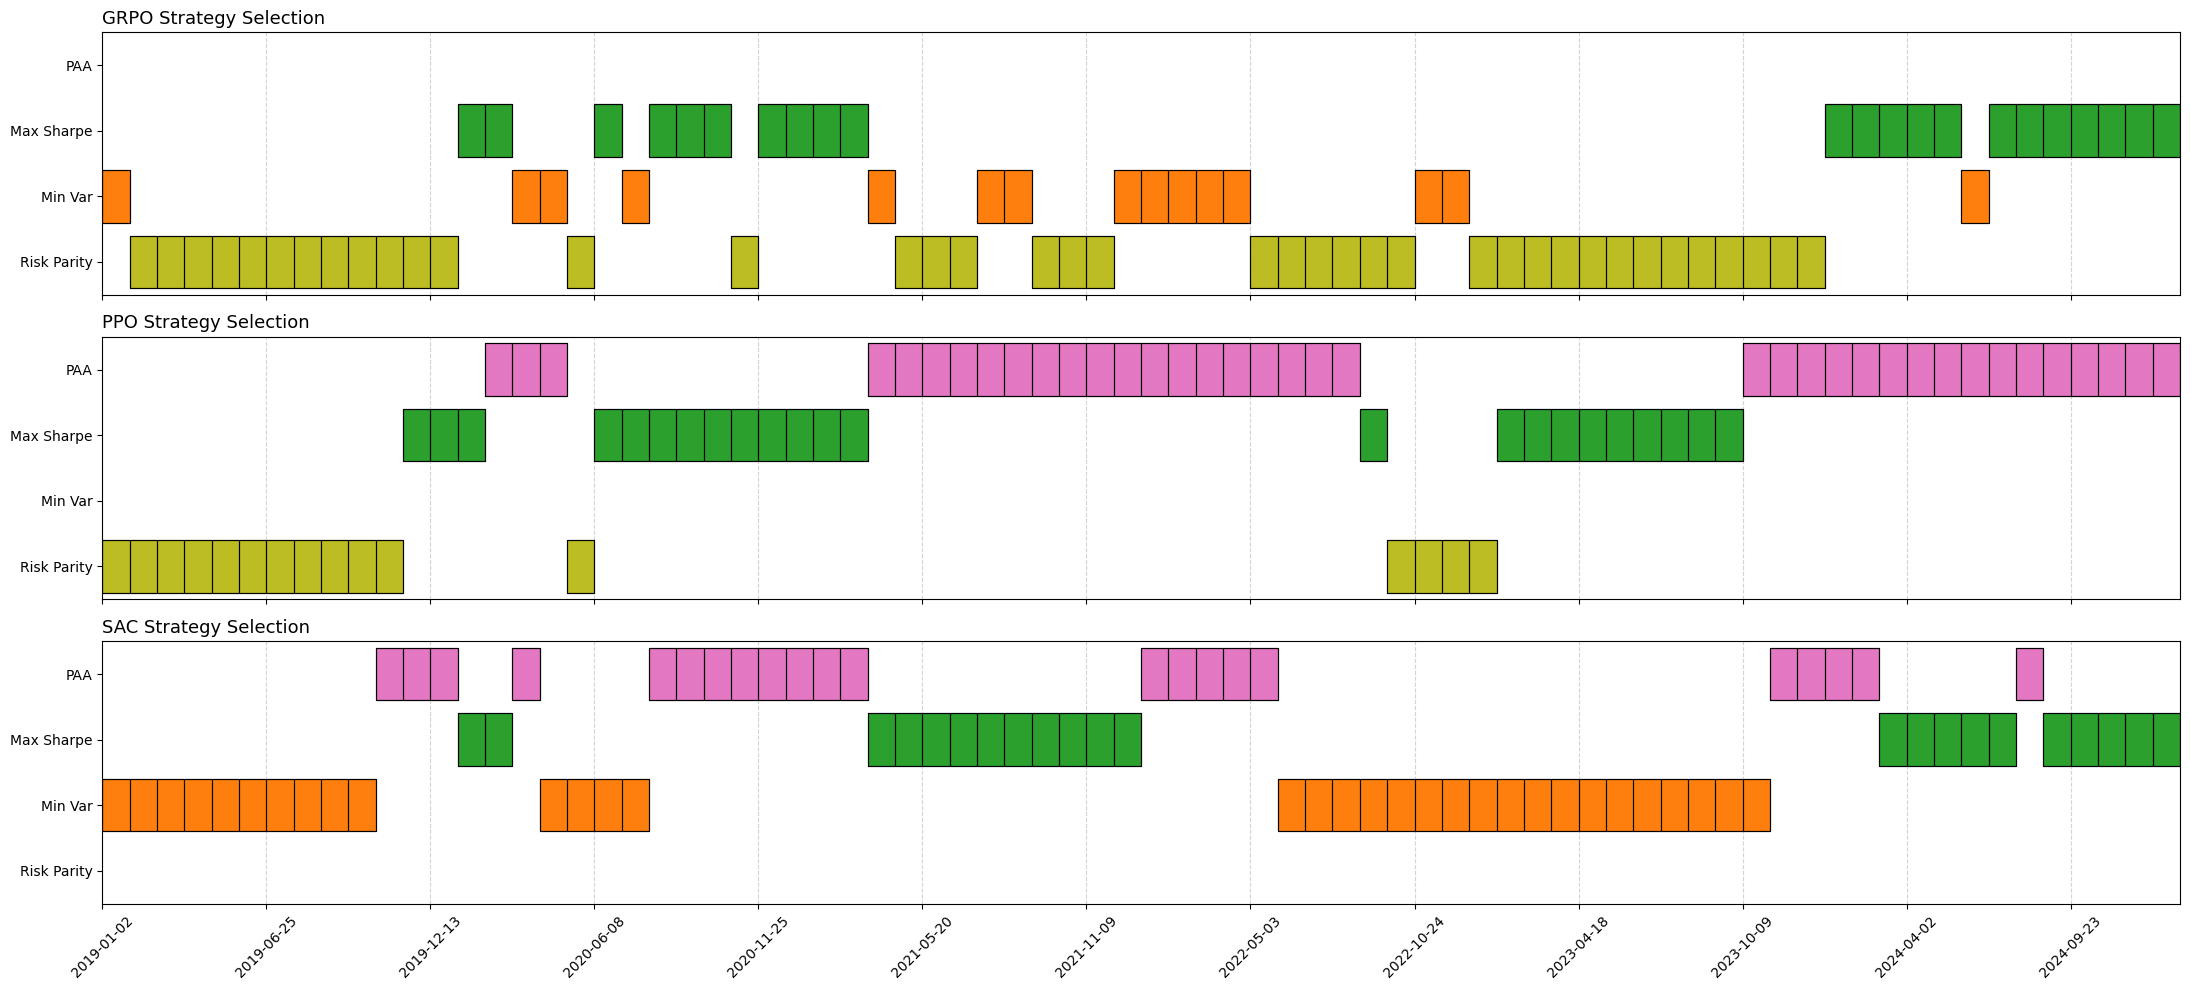

In [94]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

rebal_dict = {
    "GRPO": grpo_best_weight_rebal,
    "PPO": ppo_best_weight_rebal,
    "SAC": sac_best_weight_rebal
}

color_map = {
    'Risk Parity': '#bcbd22',
    'Min Var': '#ff7f0e',
    'Max Sharpe': '#2ca02c',
    'PAA': '#e377c2',
}
all_strats = ['Risk Parity', 'Min Var', 'Max Sharpe', 'PAA']
y_pos = {s: i for i, s in enumerate(all_strats)}

# 공통 인덱스
base_index = max(rebal_dict.values(), key=lambda df: len(df)).index
xN = len(base_index)

def ensure_cols(df, cols):
    df = df.reindex(base_index).copy()
    for c in cols:
        if c not in df.columns:
            df[c] = 0
    return df[cols].fillna(0)

def mask_to_spans(mask: np.ndarray):
    idx = np.flatnonzero(mask)
    if idx.size == 0: return []
    cuts = np.where(np.diff(idx) != 1)[0] + 1
    groups = np.split(idx, cuts)
    return [(g[0], len(g)) for g in groups]

rebal_dict = {k: ensure_cols(v, all_strats) for k, v in rebal_dict.items()}

fig, axes = plt.subplots(3, 1, figsize=(22, 10), sharex=True)

step = 6
xticks = np.arange(0, xN, step)
xticklabels = base_index[::step]

for ax, (label, df) in zip(axes, rebal_dict.items()):
    # xtick 세로줄
    for xpos in xticks:
        ax.axvline(x=xpos, color='lightgray', linestyle='--', linewidth=0.8, zorder=0)

    for strat in all_strats:
        mask = df[strat].to_numpy() == 1.0
        y0 = y_pos[strat] - 0.4
        h  = 0.8

        # 1) 연속 구간 채우기
        for start, length in mask_to_spans(mask):
            ax.broken_barh([(start, length)], (y0, h),
                           facecolors=color_map[strat],
                           edgecolors='black', linewidth=0.8, zorder=1)

            # 2) 구간 내부를 폭=1 단위 네모칸으로 분할(경계선만)
            for k in range(start, start + length):
                ax.add_patch(
                    Rectangle((k, y0), 1, h,
                              fill=False, edgecolor='black', linewidth=0.8, zorder=2)
                )

    ax.set_title(f"{label} Strategy Selection", loc='left', fontsize=13)
    ax.set_yticks(range(len(all_strats)))
    ax.set_yticklabels(all_strats)
    ax.set_ylim(-0.5, len(all_strats) - 0.5)
    ax.set_xlim(0, xN)

# x축 라벨
axes[-1].set_xticks(xticks)
axes[-1].set_xticklabels(xticklabels, rotation=45)

plt.tight_layout()
plt.savefig("./figure/strategy_selection_bar_chart.png", dpi=300)
plt.show()


In [95]:
# import pandas as pd
# import matplotlib.pyplot as plt

# rebal_dict = {
#     "GRPO": grpo_best_weight_rebal,
#     "PPO": ppo_best_weight_rebal,
#     "SAC": sac_best_weight_rebal
# }

# color_map = {
#     'risk_parity': '#bcbd22',
#     'min_var': '#ff7f0e',
#     'max_sharpe': '#2ca02c',
#     'paa': '#e377c2',
# }

# fig, axes = plt.subplots(3, 1, figsize=(22, 10), sharex=True)

# # 기준이 될 x축 범위 계산
# max_len = max(len(df) for df in rebal_dict.values())
# x = range(max_len)

# # x축 라벨용 날짜 (가장 긴 DF 기준)
# base_df = max(rebal_dict.values(), key=lambda df: len(df))
# # date_str = base_df.index.strftime('%Y-%m')
# date_str = base_df.index

# for ax, (label, df) in zip(axes, rebal_dict.items()):
#     df = df.copy().reset_index(drop=True)

#     for i, strat in enumerate(['risk_parity', 'min_var', 'max_sharpe', 'paa']):
#         y = i
#         strat_mask = (df[strat] == 1.0) if strat in df.columns else pd.Series([False] * len(df))
#         ax.bar(
#             x=pd.Series(x)[strat_mask],
#             height=0.8,
#             width=1.0,
#             bottom=y,
#             color=color_map[strat],
#             edgecolor='black',
#             align='center'
#         )

#     ax.set_title(f"{label} Strategy Selection", loc='left', fontsize=13)
#     ax.set_yticks(range(4))
#     ax.set_yticklabels(['risk_parity', 'min_var', 'max_sharpe', 'paa'])

#     # x축 설정
#     ax.set_xticks(list(x)[::6])
#     ax.set_xticklabels(date_str[::6], rotation=45)

#     # ✅ 양 끝 잘림 방지: x축 범위 여유 주기
#     ax.set_xlim(-0.5, max_len - 0.5)

# plt.tight_layout()
# plt.savefig("./figure/strategy_selection_bar_chart.png", dpi=300)
# plt.show()


In [96]:
# 모든 자산군 weight를 0 이상으로 클리핑
final_grpo_weights_with_cash = final_grpo_weights_with_cash.clip(lower=0)
final_ppo_weights_with_cash = final_ppo_weights_with_cash.clip(lower=0)
final_sac_weights_with_cash = final_sac_weights_with_cash.clip(lower=0)



In [97]:
final_sac_weights_with_cash.columns

Index(['Energy', 'Metals', 'Precious Metals', 'Agriculture',
       'Developed Equity', 'Emerging Equity', 'Cash'],
      dtype='object')

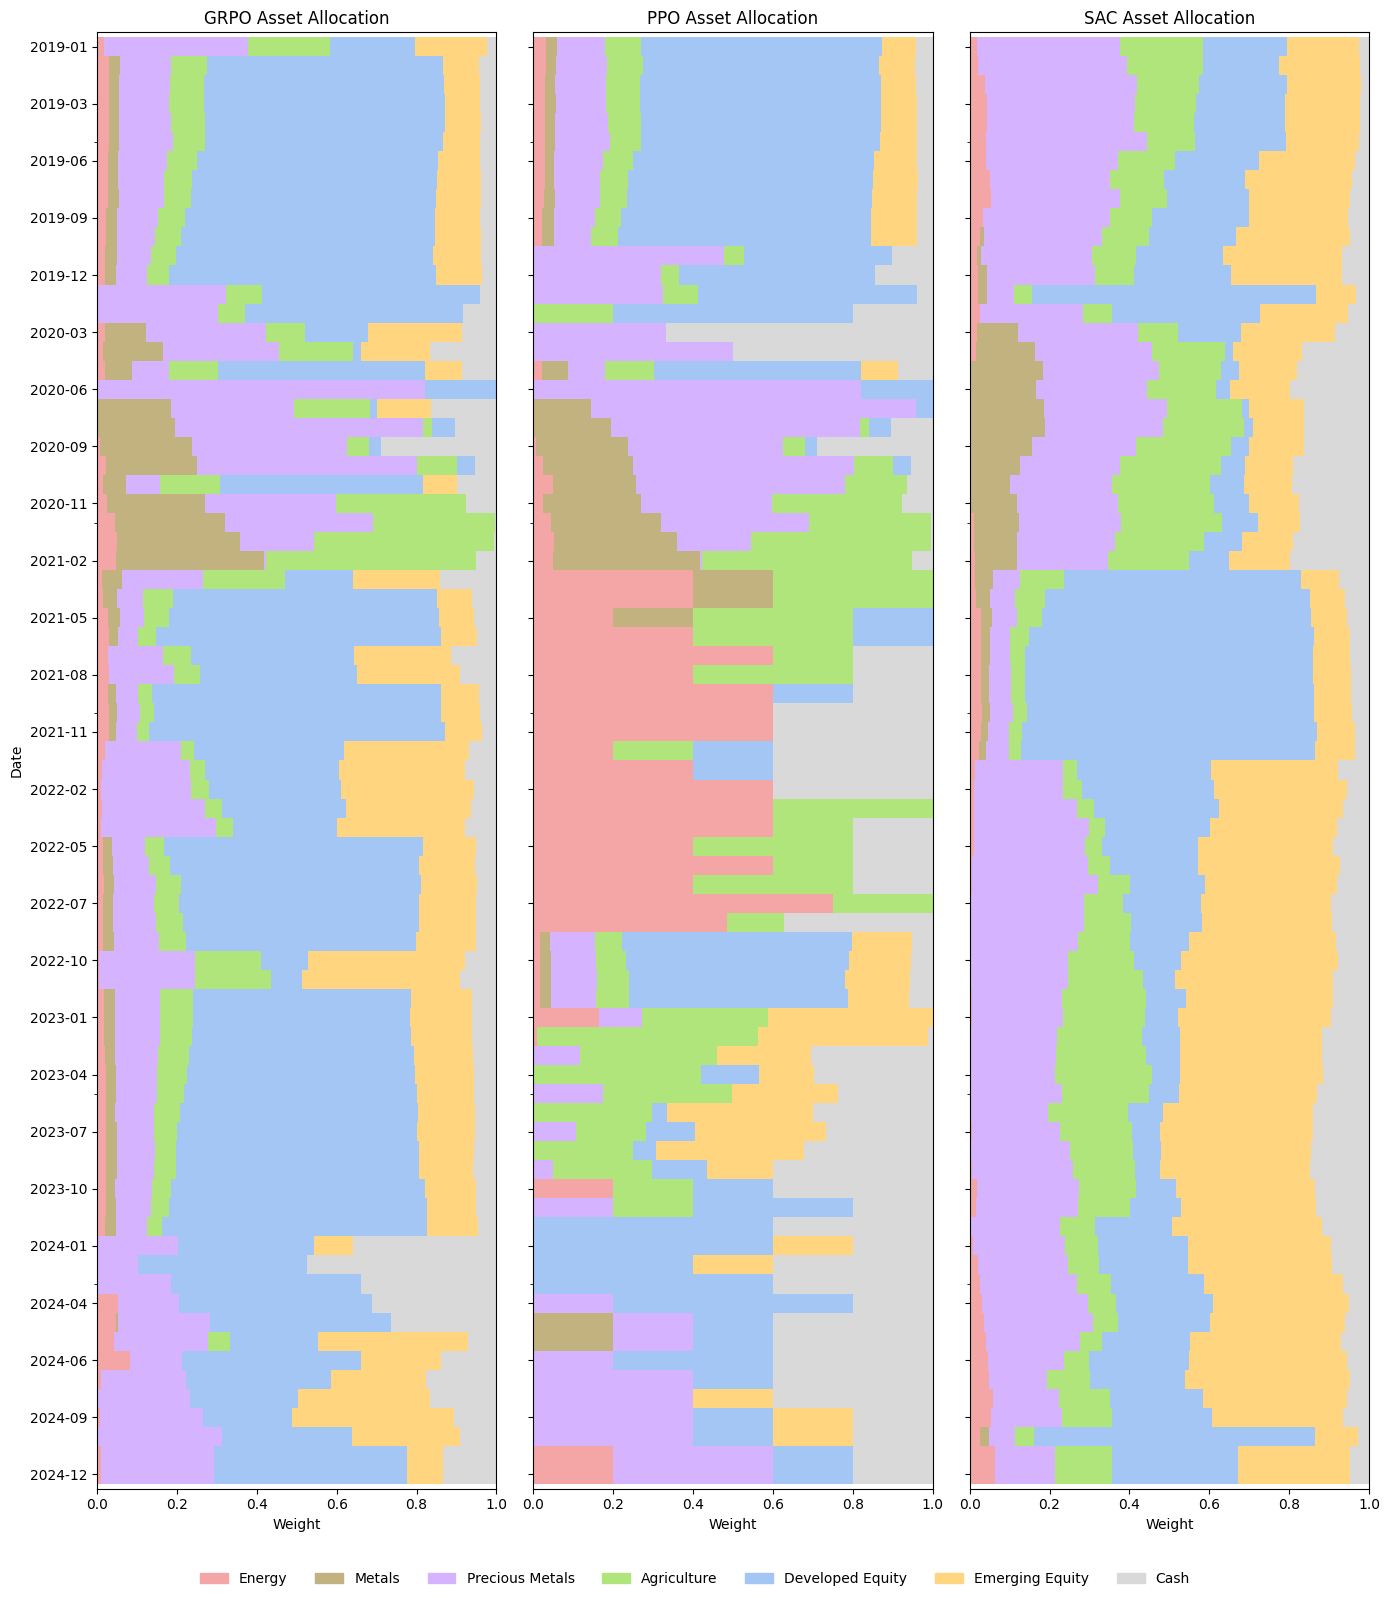

In [98]:
def plot_rotated_asset_allocation_with_fixed_ticks(grpo_df, ppo_df, sac_df):
    """
    날짜 축 문자열 변환 오류 수정 + 사용자 지정 색상 + 하단 범례 포함
    """
    fig, axes = plt.subplots(1, 3, figsize=(14, 16), sharey=True)

    models = ['GRPO', 'PPO', 'SAC']
    dataframes = [grpo_df, ppo_df, sac_df]

    # # 사용자 정의 색상 (부드러운 pastel 기반)
    # custom_colors = [
    #     "#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3",
    #     "#a6d854", "#ffd92f"
    # ]
    # color_map = dict(zip(grpo_df.columns, custom_colors))
    color_map = {
        'Energy': '#f4a6a6',            # 연한 붉은색 (Energy)
        'Metals': '#c2b280',            # 연한 갈색 (Metals)
        'Precious Metals': '#d6b3ff',   # 연보라색 (Precious Metals)
        'Agriculture': '#b0e57c',       # 연녹색 (Agriculture)
        'Developed Equity': '#a4c6f4',  # 연파랑 (Developed Equity)
        'Emerging Equity': '#ffd580',   # 연주황/피치색 (Emerging Equity)
        'Cash': '#d9d9d9'               # 연회색 (Cash)
    }


    for i, (df, ax) in enumerate(zip(dataframes, axes)):
        df_rev = df[::-1]
        df_rev.plot.barh(
            stacked=True,
            ax=ax,
            width=1.0,
            linewidth=0,
            color=[color_map[c] for c in df.columns],
            legend=False
        )
        ax.set_title(f'{models[i]} Asset Allocation', loc='center')
        ax.set_xlabel('Weight')
        ax.set_xlim(0, 1)
        ax.set_ylabel('Date')

        tick_interval = max(1, len(df) // 20)
        yticks = list(range(0, len(df), tick_interval))
        df.index = pd.to_datetime(df.index)
        yticklabels = [df.index[::-1][j].strftime("%Y-%m") for j in yticks]
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels)

    # 아래 범례
    handles = [
        plt.matplotlib.patches.Patch(color=color_map[c], label=c)
        for c in grpo_df.columns
    ]
    fig.legend(handles=handles, loc='lower center', ncol=len(grpo_df.columns), fontsize='medium', frameon=False)

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    
    plt.savefig("./figure/asset_allocation.png", dpi=300, bbox_inches='tight')
    plt.show()

# 실행
plot_rotated_asset_allocation_with_fixed_ticks(
    final_grpo_weights_with_cash,
    final_ppo_weights_with_cash,
    final_sac_weights_with_cash
)


In [66]:
final_grpo_weights_with_cash

,Energy,Metals,Precious Metals,Agriculture,Developed Equity,Emerging Equity,Cash
2019-01-02,0.000000,0.000000e+00,0.333333,3.333333e-01,0.000000,0.000000,0.333333
2019-01-31,0.030907,2.581975e-02,0.127617,9.039370e-02,0.591637,0.090379,0.043247
2019-03-01,0.029726,2.528156e-02,0.127495,8.470697e-02,0.602274,0.089282,0.041234
2019-03-29,0.044382,-2.844586e-18,0.369219,1.528692e-01,0.222369,0.189416,0.021745
2019-04-29,0.044076,-8.783448e-18,0.368456,1.495376e-01,0.228117,0.186710,0.023103
...,...,...,...,...,...,...,...
2024-08-23,0.000000,0.000000e+00,0.400000,0.000000e+00,0.000000,0.200000,0.400000
2024-09-23,0.000000,0.000000e+00,0.400000,0.000000e+00,0.200000,0.200000,0.200000
2024-10-21,0.000000,0.000000e+00,0.400000,0.000000e+00,0.200000,0.200000,0.200000
2024-11-18,0.009713,1.568372e-17,0.282433,1.707229e-16,0.484525,0.090800,0.132529


In [ ]:
imp = total_df[["equal_strategy", "equal_asset_weight"]]

In [ ]:
imp.to_csv("./portfolio_price_discrete_rebal_step_1m_concat_asset/result/equal_strategy.csv")